# 4/2/26 - AdvaitaBio Analysis Pipeline Test

In [1]:
import os
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler as dc
from sklearn.preprocessing import StandardScaler
import json
from tqdm.notebook import tqdm

/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:504: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enu

## Part 1 - Data Ingestion and Preprocessing
Using this as reference: https://scanpy-tutorials.readthedocs.io/en/multiomics/analysis-visualization-spatial.html

### Load Data

In [2]:
anndata_file = './731fb49f-4a81-48d5-9f28-ee1b08f1018d.h5ad'
adata = sc.read_h5ad(anndata_file)

In [3]:
adata

AnnData object with n_obs × n_vars = 4992 × 35476
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'is_primary_data', 'donor_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'q05cell_abundance_w_sf_Cardiac', 'q05cell_abundance_w_sf_Endothelial', 'q05cell_abundance_w_sf_Immune', 'q05cell_abundance_w_sf_Mesenchymal_clust12', 'q05cell_abundance_w_sf_Mesenchymal_clust15', 'q05cell_abundance_w_sf_Mesenchymal_clust3', 'q05cell_abundance_w_sf_Mesenchymal_clust6', 'q05cell_abundance_w_sf_Mesenchymal_clust9', 'q05cell_abundance_w_sf_Neural', 'annotation', 'cell_type_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'featur

### QC Metrics

In [4]:
# Set var index to gene symbols instead of ensembl IDs
adata.var['ensemble_id'] = adata.var.index
adata.var['feature_name'] = adata.var['feature_name'].astype(str)
adata.var.set_index('feature_name', inplace=True)

In [5]:
adata.var_names_make_unique()

In [6]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

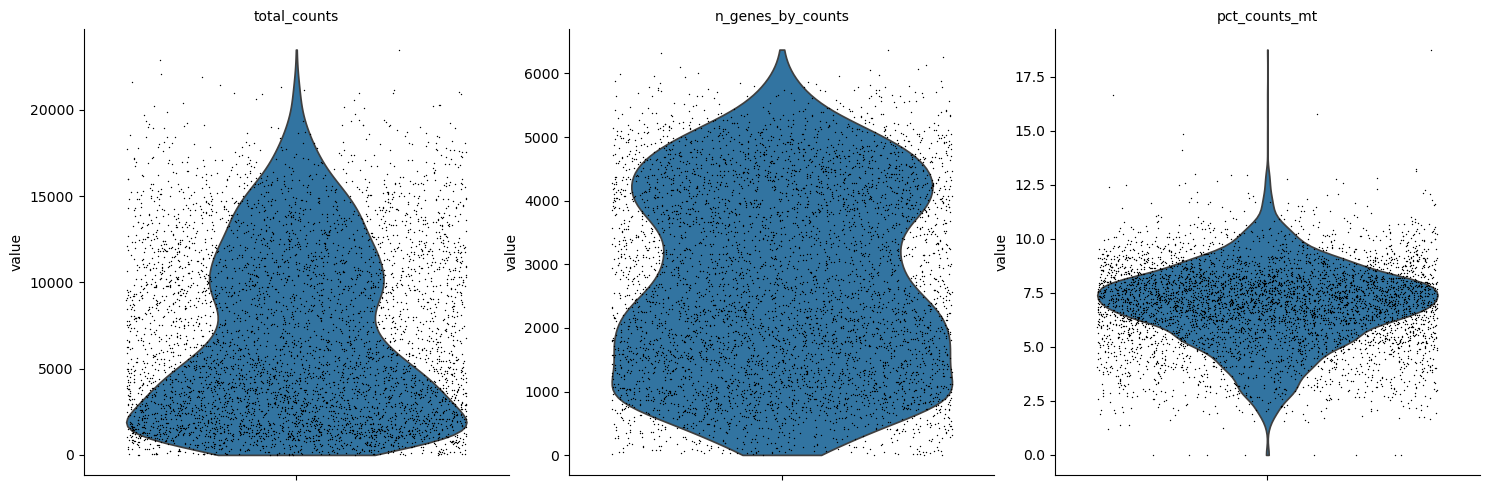

In [7]:
sc.pl.violin(
    adata,
    ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

### Filtering

In [8]:
adata

AnnData object with n_obs × n_vars = 4992 × 35476
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'is_primary_data', 'donor_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'q05cell_abundance_w_sf_Cardiac', 'q05cell_abundance_w_sf_Endothelial', 'q05cell_abundance_w_sf_Immune', 'q05cell_abundance_w_sf_Mesenchymal_clust12', 'q05cell_abundance_w_sf_Mesenchymal_clust15', 'q05cell_abundance_w_sf_Mesenchymal_clust3', 'q05cell_abundance_w_sf_Mesenchymal_clust6', 'q05cell_abundance_w_sf_Mesenchymal_clust9', 'q05cell_abundance_w_sf_Neural', 'annotation', 'cell_type_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_

In [9]:
# Filter out spots with less than 8000 total counts or more than 20% mito counts
adata = adata[
    (adata.obs['total_counts'] > 9000) &
    (adata.obs['pct_counts_mt'] < 20)
].copy()

In [11]:
adata

AnnData object with n_obs × n_vars = 1706 × 35476
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'is_primary_data', 'donor_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'q05cell_abundance_w_sf_Cardiac', 'q05cell_abundance_w_sf_Endothelial', 'q05cell_abundance_w_sf_Immune', 'q05cell_abundance_w_sf_Mesenchymal_clust12', 'q05cell_abundance_w_sf_Mesenchymal_clust15', 'q05cell_abundance_w_sf_Mesenchymal_clust3', 'q05cell_abundance_w_sf_Mesenchymal_clust6', 'q05cell_abundance_w_sf_Mesenchymal_clust9', 'q05cell_abundance_w_sf_Neural', 'annotation', 'cell_type_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_

In [13]:
# Filter spots with less than 200 genes, and genes only present in 3 spots
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [14]:
adata

AnnData object with n_obs × n_vars = 1706 × 19132
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'is_primary_data', 'donor_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'q05cell_abundance_w_sf_Cardiac', 'q05cell_abundance_w_sf_Endothelial', 'q05cell_abundance_w_sf_Immune', 'q05cell_abundance_w_sf_Mesenchymal_clust12', 'q05cell_abundance_w_sf_Mesenchymal_clust15', 'q05cell_abundance_w_sf_Mesenchymal_clust3', 'q05cell_abundance_w_sf_Mesenchymal_clust6', 'q05cell_abundance_w_sf_Mesenchymal_clust9', 'q05cell_abundance_w_sf_Neural', 'annotation', 'cell_type_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_

### Normalization

In [15]:
## Median normalize and log1p transform
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

### HVGs and Clustering

In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000)

In [17]:
sc.tl.pca(adata)

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50) #6 immediate neighbor spots?

In [19]:
sc.tl.umap(adata)

In [20]:
sc.tl.leiden(adata, resolution=0.5)

/var/folders/24/rz3s2f2s1476xvk4f_cxtbqh0000gn/T/ipykernel_21231/1771924308.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


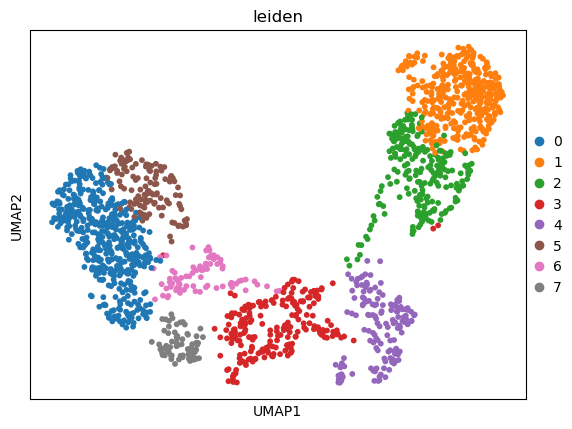

In [21]:
sc.pl.umap(adata, color='leiden')

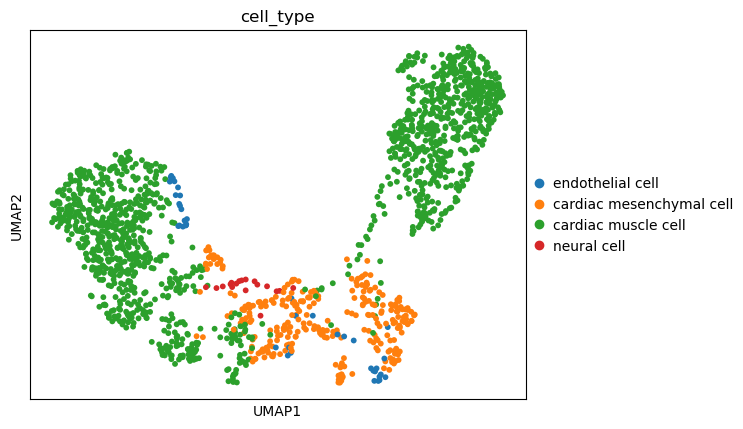

In [22]:
sc.pl.umap(adata, color='cell_type')

## Part 2 - Ligand-receptor analysis

### Run spatial neighbors and ligand-receptor analysis

In [23]:
sq.gr.spatial_neighbors(adata)

In [24]:
# Run squidpy ligand-receptor analysis - fast python implementation of CellPhoneDB
sq.gr.ligrec(
    adata,
    cluster_key='cell_type',
    n_perms=100,
    use_raw=False
)

2026-04-03 21:44:28 | [INFO] Downloading data from `https://omnipathdb.org/queries/enzsub?format=json`
2026-04-03 21:44:28 | [INFO] Downloading data from `https://omnipathdb.org/queries/interactions?format=json`
2026-04-03 21:44:29 | [INFO] Downloading data from `https://omnipathdb.org/queries/complexes?format=json`
2026-04-03 21:44:29 | [INFO] Downloading data from `https://omnipathdb.org/queries/annotations?format=json`
2026-04-03 21:44:29 | [INFO] Downloading data from `https://omnipathdb.org/queries/intercell?format=json`
2026-04-03 21:44:30 | [INFO] Downloading data from `https://omnipathdb.org/about?format=text`


  0%|          | 0/100 [00:00<?, ?permutation/s]

/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:504: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enu

### Get results and format

In [25]:
ligrec_result = adata.uns['cell_type_ligrec']

In [26]:
means = ligrec_result['means']
pvals = ligrec_result['pvalues']

In [27]:
# Convert to long-form dataframe
df_means = means.stack([0, 1]).reset_index()
df_means.columns = ['ligand', 'receptor', 'source', 'target', 'mean']

df_pvals = pvals.stack([0, 1]).reset_index()
df_pvals.columns = ['ligand', 'receptor', 'source', 'target', 'pval']

/var/folders/24/rz3s2f2s1476xvk4f_cxtbqh0000gn/T/ipykernel_21231/4274670603.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_means = means.stack([0, 1]).reset_index()
/var/folders/24/rz3s2f2s1476xvk4f_cxtbqh0000gn/T/ipykernel_21231/4274670603.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_pvals = pvals.stack([0, 1]).reset_index()


In [28]:
# Merge means and pval dataframes
df = df_means.merge(
    df_pvals,
    on=['ligand', 'receptor', 'source', 'target']
)

In [29]:
# Filter to just significant results
df_sig = df[df['pval'] < 0.05].copy()

In [30]:
df_sig

,ligand,receptor,source,target,mean,pval
4,FYN,TRPC6,endothelial cell,endothelial cell,0.361324,0.0
5,FYN,TRPC6,endothelial cell,neural cell,0.38303,0.0
6,FYN,TRPC6,neural cell,endothelial cell,0.384018,0.0
7,FYN,TRPC6,neural cell,neural cell,0.405724,0.0
8,FYN,TRPV4,endothelial cell,neural cell,0.391157,0.0
...,...,...,...,...,...,...
16894,EGF,OPRM1,endothelial cell,neural cell,0.106451,0.0
16903,ANPEP,BCKDK,endothelial cell,endothelial cell,0.358154,0.0
16904,ANPEP,BCKDK,endothelial cell,neural cell,0.422382,0.0
16911,FYN,F2R,endothelial cell,endothelial cell,0.789903,0.0


In [31]:
adata.obs['cell_type'].unique()

['cardiac muscle cell', 'cardiac mesenchymal cell', 'endothelial cell', 'neural cell']
Categories (4, object): ['endothelial cell', 'cardiac mesenchymal cell', 'cardiac muscle cell', 'neural cell']

### Summarize results/plot

In [32]:
# Cell-cell interaction counts
interaction_summary = (
    df_sig.groupby(['source', 'target'])
    .size()
    .reset_index(name='count')
)
interaction_summary

,source,target,count
0,endothelial cell,endothelial cell,1803
1,endothelial cell,neural cell,1506
2,neural cell,endothelial cell,1440
3,neural cell,neural cell,1194


In [33]:
# Source only interaction counts
outgoing = (
    interaction_summary.groupby('source')['count']
    .sum()
    .sort_values(ascending=False)
)
outgoing

source
endothelial cell    3309
neural cell         2634
Name: count, dtype: int64

In [34]:
# Target only interaction counts
incoming = (
    interaction_summary.groupby('target')['count']
    .sum()
    .sort_values(ascending=False)
)
incoming

target
endothelial cell    3243
neural cell         2700
Name: count, dtype: int64

Text(0.5, 1.0, 'Cell–Cell Interaction Counts')

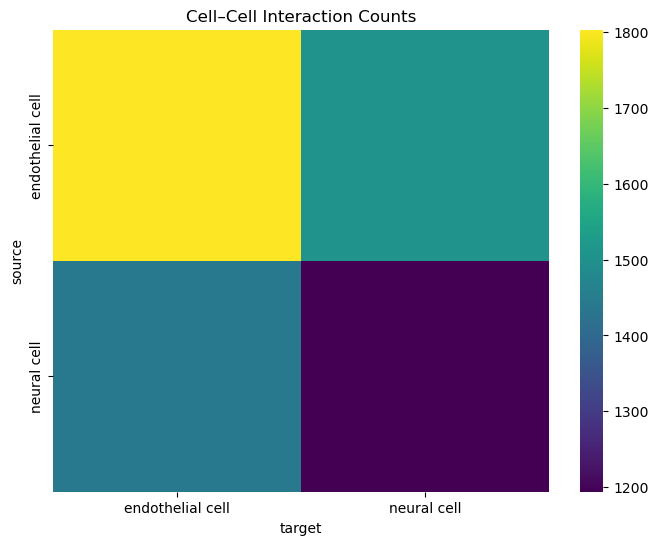

In [35]:
# Heatmap of interactions
pivot = interaction_summary.pivot(
    index='source',
    columns='target',
    values='count'
).fillna(0)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap='viridis')
plt.title("Cell–Cell Interaction Counts")

In [36]:
# Top ligand-receptor pairs
top_pairs = (
    df_sig.sort_values('mean', ascending=False)
    .head(20)
)
top_pairs

,ligand,receptor,source,target,mean,pval
11720,SPARC,MMP14,neural cell,endothelial cell,2.580874,0.0
11721,SPARC,MMP14,neural cell,neural cell,2.562891,0.0
7972,SPARC,FGFR1,neural cell,endothelial cell,2.515147,0.0
7973,SPARC,FGFR1,neural cell,neural cell,2.477398,0.0
11718,SPARC,MMP14,endothelial cell,endothelial cell,2.363313,0.0
11719,SPARC,MMP14,endothelial cell,neural cell,2.345329,0.0
6155,MDK,ITGB1,neural cell,endothelial cell,2.304616,0.0
7970,SPARC,FGFR1,endothelial cell,endothelial cell,2.297585,0.0
6156,MDK,ITGB1,neural cell,neural cell,2.275207,0.0
13950,CALR,P4HB,endothelial cell,endothelial cell,2.275172,0.0


In [37]:
# Top 3 ligand receptor pairs per set of cell type pairs
top_per_pair = (
    df_sig.groupby(['source', 'target'])
    .apply(lambda x: x.nlargest(3, 'mean'))
    .reset_index(drop=True)
)
top_per_pair

/var/folders/24/rz3s2f2s1476xvk4f_cxtbqh0000gn/T/ipykernel_21231/309780408.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'mean'))


,ligand,receptor,source,target,mean,pval
0,SPARC,MMP14,endothelial cell,endothelial cell,2.363313,0.0
1,SPARC,FGFR1,endothelial cell,endothelial cell,2.297585,0.0
2,CALR,P4HB,endothelial cell,endothelial cell,2.275172,0.0
3,SPARC,MMP14,endothelial cell,neural cell,2.345329,0.0
4,SPARC,FGFR1,endothelial cell,neural cell,2.259837,0.0
5,FYN,TUBA1A,endothelial cell,neural cell,2.223565,0.0
6,SPARC,MMP14,neural cell,endothelial cell,2.580874,0.0
7,SPARC,FGFR1,neural cell,endothelial cell,2.515147,0.0
8,MDK,ITGB1,neural cell,endothelial cell,2.304616,0.0
9,SPARC,MMP14,neural cell,neural cell,2.562891,0.0


In [38]:
sq.gr.nhood_enrichment(adata, cluster_key='cell_type')

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:504: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enu

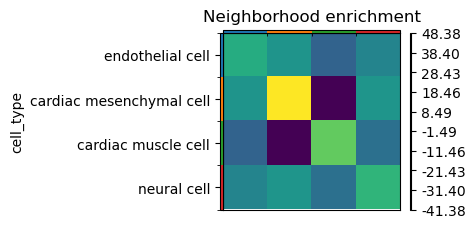

In [39]:
sq.pl.nhood_enrichment(adata, cluster_key="cell_type")

## Part 3 - Pathway Analysis (Decoupler)

In [40]:
# Get MSigDB Hallmark gene sets
hallmark_gene_sets = dc.op.hallmark(organism='human')

In [41]:
# Run enrichment analysis via ulm method (as recommended by https://decoupler.readthedocs.io/en/latest/notebooks/spatial/rna_visium.html)
dc.mt.ulm(data=adata, net=hallmark_gene_sets)

In [42]:
# Get scores and pvals in dataframes
pathway_scores = pd.DataFrame(
    adata.obsm['score_ulm'],
    index=adata.obs_names
)

pathway_pvals = pd.DataFrame(
    adata.obsm['padj_ulm'],
    index=adata.obs_names
)

In [43]:
# Filter non-significant pathways scores by setting to 0
pathway_scores_filtered = pathway_scores.copy()
pathway_scores_filtered[pathway_pvals > 0.05] = 0

In [44]:
# Scale pathway scores
scaler = StandardScaler()
pathway_scaled = scaler.fit_transform(pathway_scores_filtered)

In [45]:
# Convert to labeled dataframe
pathway_scaled_df = pd.DataFrame(pathway_scaled, index=adata.obsm['score_ulm'].index, columns=adata.obsm['score_ulm'].columns)

In [46]:
# Add back to adata obsm field
adata.obsm['score_ulm_scaled'] = pathway_scaled_df

In [47]:
# Run nearest neighbors and leiden on scaled pathway data
sc.pp.neighbors(adata, use_rep="score_ulm_scaled", n_neighbors=15)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_pathways')

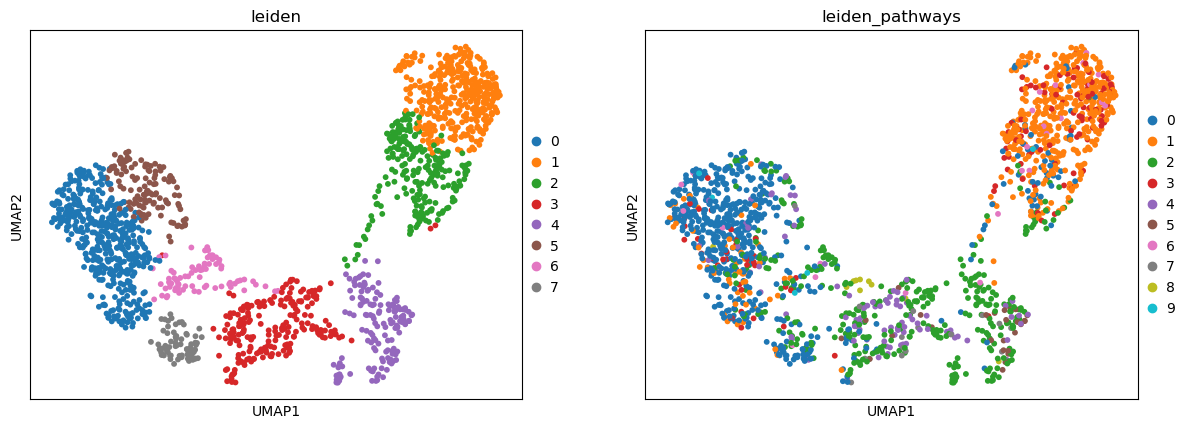

In [48]:
# Plot gene expression based and pathway score based leiden clusters
sc.pl.umap(adata, color=['leiden', 'leiden_pathways'])

In [49]:
# Delete extra entry in spatial dict
del adata.uns['spatial']['is_single']

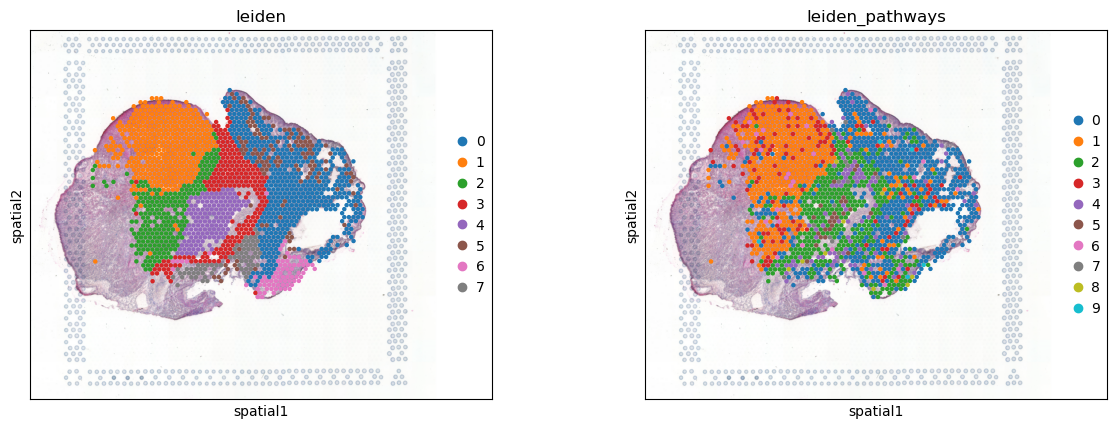

In [64]:
# Plot gene expression based and pathway score based leiden clusters spatially
ax = sq.pl.spatial_scatter(
    adata,
    color=["leiden", "leiden_pathways"],
    library_key="Rotem_12W_heart_A1",
    size=1.5,
    cmap="tab20",
    legend_loc='right',
    return_ax=True
)
for subax in ax:
    subax.invert_yaxis()

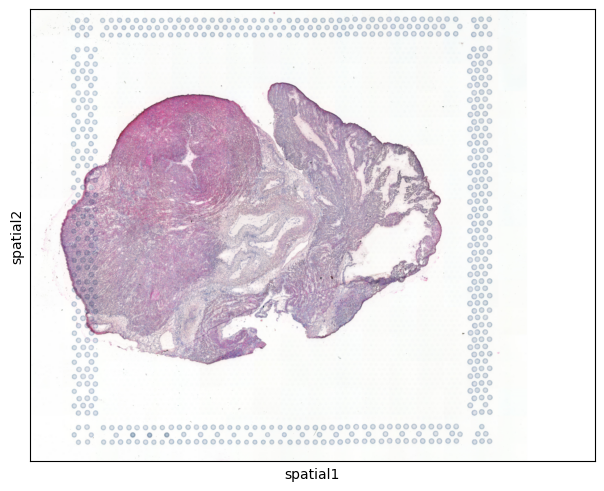

In [65]:
# Plot gene expression based and pathway score based leiden clusters spatially
ax = sq.pl.spatial_scatter(
    adata,
    library_key="Rotem_12W_heart_A1",
    size=1.5,
    cmap="tab20",
    legend_loc='right',
    return_ax=True
)
ax.invert_yaxis()

## Export data to JSON file

In [66]:
spots = []
# Grab the two clustering schemes
pathway_clusters = adata.obs['leiden_pathways'].values
leiden_clusters = adata.obs['leiden'].values

# Select the 3000 highly variable genes for now
genes_of_interest = adata.var[adata.var['highly_variable']].index.tolist()
gene_data = adata[:, genes_of_interest].X 
# Convert sparse matrix to array
gene_data = gene_data.toarray()

for i in tqdm(range(adata.n_obs)):
    # Get spot coords and both gene expression and pathway-based leiden clusters
    spot = {
        "x": float(adata.obsm['spatial'][i, 0]),
        "y": float(adata.obsm['spatial'][i, 1]),
        "pathway_leiden_cluster": str(pathway_clusters[i]),
        "gene_exp_leiden_cluster": str(leiden_clusters[i])
    }
    # Add gene expression
    for j, gene in enumerate(genes_of_interest):
        spot[gene] = float(gene_data[i, j])
    spots.append(spot)

# **Interaction Data**
interactions = []
# Iterate through the significant pairs dataframe and convert to dict
for _, row in tqdm(df_sig.iterrows()):
    interactions.append({
        "source": row["source"],
        "target": row["target"],
        "ligand": row["ligand"],
        "receptor": row["receptor"],
        "mean": float(row["mean"]),
        "pval": float(row["pval"])
    })

# Combine into a single dictionary
export_dict = {
    "spots": spots,
    "interactions": interactions
}

# Write to JSON
with open("./visium_export.json", "w") as f:
    json.dump(export_dict, f, indent=2)

  0%|          | 0/1706 [00:00<?, ?it/s]

0it [00:00, ?it/s]

/Users/milan/miniforge3/envs/python313/lib/python3.13/site-packages/tqdm/std.py:1181: PerformanceWarning: Concatenating sparse arrays with multiple fill values: '[0, nan]'. Picking the first and converting the rest.
  for obj in iterable:
